# Customer Shopping Behavior Analysis

## Project Overview
This project analyzes customer shopping behavior using customer, product, purchase, promotion, and customer experience data.

The analysis focuses on identifying patterns in:
- Customer engagement
- Promotional behavior
- Product performance
- Purchase frequency
- Customer experience

The goal is to **transform raw shopping data into business insights
that can support marketing and customer strategy decisions**.

### Tools
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

### Analytical Approach
Business Question → Data Understanding → Data Cleaning → EDA
→ Analysis → Insight → Business Recommendation

## Import Library, Dataset, and CSV

###Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Visualization style
sns.set_theme(style="whitegrid")

### Load Dataset

In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "iamsouravbanerjee/customer-shopping-trends-dataset"
)

print("Dataset downloaded to:")
print(path)

100%|██████████| 146k/146k [00:00<00:00, 23.4MB/s]

Extracting files...
Dataset downloaded to:
/root/.cache/kagglehub/datasets/iamsouravbanerjee/customer-shopping-trends-dataset/versions/2


Check File

In [ ]:
import os

files = os.listdir(path)

print("Files in dataset folder:")
for file in files:
    print(file)

Files in dataset folder:
shopping_trends_updated.csv
shopping_trends.csv


### Load CSV

In [ ]:
csv_path = os.path.join(
    path,
    'shopping_trends_updated.csv'
)

df = pd.read_csv(csv_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


## Dataset Overview (Business Understanding)

### Checking & Showing Dataset

In [ ]:
# Ukuran Dataset
print(f"Number of rows    : {df.shape[0]:,}")
print(f"Number of columns : {df.shape[1]:,}")

Number of rows    : 3,900
Number of columns : 18


In [ ]:
# 5 First Data
print("First 5 Data:")
display(df.head())

# 5 Last Data
print("Last 5 Data:")
display(df.tail())

First 5 Data:


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.10,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.10,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.10,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.50,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.70,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


Last 5 Data:


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.20,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.50,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.90,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.80,No,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.10,No,Store Pickup,No,No,33,Venmo,Quarterly


In [ ]:
# Column Name

print("Columns:")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns:
1. Customer ID
2. Age
3. Gender
4. Item Purchased
5. Category
6. Purchase Amount (USD)
7. Location
8. Size
9. Color
10. Season
11. Review Rating
12. Subscription Status
13. Shipping Type
14. Discount Applied
15. Promo Code Used
16. Previous Purchases
17. Payment Method
18. Frequency of Purchases


### Missing Values

In [ ]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': (
        missing_values / len(df) * 100
    ).round(2)
})

display(missing_summary)


,Missing Values,Percentage (%)
Customer ID,0,0.00
Age,0,0.00
Gender,0,0.00
Item Purchased,0,0.00
Category,0,0.00
Purchase Amount (USD),0,0.00
Location,0,0.00
Size,0,0.00
Color,0,0.00
Season,0,0.00


In [ ]:
print(
    "Total missing values:",
    df.isnull().sum().sum()
)

Total missing values: 0


### Duplicate Values

In [ ]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


### Customer ID Check

In [ ]:
unique_customers = df['Customer ID'].nunique()

print("Total rows:", len(df))
print("Unique Customer IDs:", unique_customers)

print(
    "Customer ID is unique:",
    unique_customers == len(df)
)

Total rows: 3900
Unique Customer IDs: 3900
Customer ID is unique: True


In [ ]:
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.00,3900.00,3900.00,3900.00,3900.00
mean,1950.50,44.07,59.76,3.75,25.35
std,1125.98,15.21,23.69,0.72,14.45
min,1.00,18.00,20.00,2.50,1.00
25%,975.75,31.00,39.00,3.10,13.00
50%,1950.50,44.00,60.00,3.70,25.00
75%,2925.25,57.00,81.00,4.40,38.00
max,3900.00,70.00,100.00,5.00,50.00


### Categorical Variables

In [ ]:
categorical_columns = df.select_dtypes(
    include='object'
).columns

print("Categorical columns:")
for column in categorical_columns:
    print(column)

Categorical columns:
Gender
Item Purchased
Category
Location
Size
Color
Season
Subscription Status
Shipping Type
Discount Applied
Promo Code Used
Payment Method
Frequency of Purchases


In [ ]:
for column in categorical_columns:

    print("\n" + "=" * 60)
    print(column)

    print(df[column].value_counts())


Gender
Gender
Male      2652
Female    1248
Name: count, dtype: int64

Item Purchased
Item Purchased
Blouse        171
Pants         171
Jewelry       171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Coat          161
Sunglasses    161
Belt          161
Sandals       160
Socks         159
Skirt         158
Scarf         157
Shorts        157
Hat           154
Handbag       153
Hoodie        151
Shoes         150
T-shirt       147
Sneakers      145
Boots         144
Backpack      143
Gloves        140
Jeans         124
Name: count, dtype: int64

Category
Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

Location
Location
Montana           96
California        95
Idaho             93
Illinois          92
Alabama           89
Minnesota         88
New York          87
Nevada            87
Nebraska          87
Delaware          86
Maryland          86
Vermont           85
Louisiana         84
North

### Unique Values

In [ ]:
for column in df.columns:
    print(
        f"{column}: {df[column].nunique()} unique values"
    )

Customer ID: 3900 unique values
Age: 53 unique values
Gender: 2 unique values
Item Purchased: 25 unique values
Category: 4 unique values
Purchase Amount (USD): 81 unique values
Location: 50 unique values
Size: 4 unique values
Color: 25 unique values
Season: 4 unique values
Review Rating: 26 unique values
Subscription Status: 2 unique values
Shipping Type: 6 unique values
Discount Applied: 2 unique values
Promo Code Used: 2 unique values
Previous Purchases: 50 unique values
Payment Method: 6 unique values
Frequency of Purchases: 7 unique values


## Data Cleaning & EDA

In [ ]:
df_clean = df.copy()

In [ ]:
# Standardize Column Names

df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace(r'[()]', '', regex=True)
)

display(df_clean.columns)

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

### Categorical Consistency

In [ ]:
categorical_columns = df_clean.select_dtypes(
    include='object'
).columns

for column in categorical_columns:

    print("\n" + "=" * 60)
    print(column)

    print(
        df_clean[column].unique()
    )


gender
['Male' 'Female']

item_purchased
['Blouse' 'Sweater' 'Jeans' 'Sandals' 'Sneakers' 'Shirt' 'Shorts' 'Coat'
 'Handbag' 'Shoes' 'Dress' 'Skirt' 'Sunglasses' 'Pants' 'Jacket' 'Hoodie'
 'Jewelry' 'T-shirt' 'Scarf' 'Hat' 'Socks' 'Backpack' 'Belt' 'Boots'
 'Gloves']

category
['Clothing' 'Footwear' 'Outerwear' 'Accessories']

location
['Kentucky' 'Maine' 'Massachusetts' 'Rhode Island' 'Oregon' 'Wyoming'
 'Montana' 'Louisiana' 'West Virginia' 'Missouri' 'Arkansas' 'Hawaii'
 'Delaware' 'New Hampshire' 'New York' 'Alabama' 'Mississippi'
 'North Carolina' 'California' 'Oklahoma' 'Florida' 'Texas' 'Nevada'
 'Kansas' 'Colorado' 'North Dakota' 'Illinois' 'Indiana' 'Arizona'
 'Alaska' 'Tennessee' 'Ohio' 'New Jersey' 'Maryland' 'Vermont'
 'New Mexico' 'South Carolina' 'Idaho' 'Pennsylvania' 'Connecticut' 'Utah'
 'Virginia' 'Georgia' 'Nebraska' 'Iowa' 'South Dakota' 'Minnesota'
 'Washington' 'Wisconsin' 'Michigan']

size
['L' 'S' 'M' 'XL']

color
['Gray' 'Maroon' 'Turquoise' 'White' 'Charcoal'

### Redundants Columns

In [ ]:
discount_promo_same = (
    df_clean['discount_applied']
    ==
    df_clean['promo_code_used']
).all()

print(
    "Discount Applied and Promo Code Used identical:",
    discount_promo_same
)

Discount Applied and Promo Code Used identical: True


In [ ]:
if discount_promo_same:

    df_clean = df_clean.drop(
        columns=['promo_code_used']
    )

    print(
        "promo_code_used removed because it is redundant."
    )

promo_code_used removed because it is redundant.


In [ ]:
df_clean = df_clean.drop(
    columns=['customer_promotion_group'],
    errors='ignore'
)

**Standardizing Purchase Frequency!!!**

The dataset contains multiple labels that represent the same purchasing interval:

- `Bi-Weekly` and `Fortnightly` represent purchases approximately every two weeks.
- `Quarterly` and `Every 3 Months` represent purchases approximately every three months.

These categories are standardized to avoid splitting the same purchasing behavior into separate groups during analysis.

In [ ]:
# Standardize purchase frequency categories

frequency_mapping = {
    'Weekly': 'Weekly',
    'Bi-Weekly': 'Bi-Weekly',
    'Fortnightly': 'Bi-Weekly',
    'Monthly': 'Monthly',
    'Quarterly': 'Quarterly',
    'Every 3 Months': 'Quarterly',
    'Annually': 'Annually'
}

df_clean['frequency_standardized'] = (
    df_clean['frequency_of_purchases']
    .map(frequency_mapping)
)

print("Original frequency categories:")
display(df_clean['frequency_of_purchases'].value_counts())

print("\nStandardized frequency categories:")
display(df_clean['frequency_standardized'].value_counts())

Original frequency categories:


,count
frequency_of_purchases,
Every 3 Months,584
Annually,572
Quarterly,563
Monthly,553
Bi-Weekly,547
Fortnightly,542
Weekly,539



Standardized frequency categories:


,count
frequency_standardized,
Quarterly,1147
Bi-Weekly,1089
Annually,572
Monthly,553
Weekly,539


### Verify Cleaning

In [ ]:
print(
    "Total missing values:",
    df_clean.isnull().sum().sum()
)

print(
    "Duplicate rows:",
    df_clean.duplicated().sum()
)

print(
    "Number of columns:",
    df_clean.shape[1]
)

Total missing values: 0
Duplicate rows: 0
Number of columns: 18


## Data Limitation

Several limitations should be considered when interpreting the results:

1. Each 'Customer ID' appears only once in the dataset. Therefore, the dataset is treated as customer-level shopping behavior data rather than a multi-transaction customer history.

2. The dataset does not contain transaction dates, so temporal trends, cohort analysis, and true recency analysis cannot be performed.

3. `Discount Applied` and `Promo Code Used` contain identical information, so `Promo Code Used` was removed as a redundant variable.

4. All subscribers in the dataset are associated with discount usage. Therefore, the dataset does not provide a subscriber-without-discount comparison group.

5. Purchase frequency contains semantically overlapping labels, which were standardized before analysis.

6. The analysis describes associations and patterns in the dataset and does not establish causal relationships.

## Analysis

### KPI Overview

**KPI Overview**

The following KPIs provide a high-level overview of the customer shopping behavior dataset.

Because each Customer ID appears only once, the dataset is treated as a **customer-level dataset** rather than a multi-transaction customer history.

Key metrics include:
- Total Customers
- Total Purchase Amount
- Average Purchase Amount
- Average Review Rating
- Average Previous Purchases
- Subscription Rate

In [ ]:
# KPI Overview

total_customers = df_clean['customer_id'].nunique()

total_purchase_amount = (
    df_clean['purchase_amount_usd'].sum()
)

average_purchase_amount = (
    df_clean['purchase_amount_usd'].mean()
)

average_rating = (
    df_clean['review_rating'].mean()
)

average_previous_purchases = (
    df_clean['previous_purchases'].mean()
)

subscription_rate = (
    df_clean['subscription_status']
    .eq('Yes')
    .mean() * 100
)

print(f"Total Customers          : {total_customers:,}")
print(f"Total Purchase Amount    : ${total_purchase_amount:,.2f}")
print(f"Average Purchase Amount  : ${average_purchase_amount:,.2f}")
print(f"Average Review Rating    : {average_rating:.2f}")
print(f"Avg Previous Purchases   : {average_previous_purchases:.2f}")
print(f"Subscription Rate        : {subscription_rate:.2f}%")

Total Customers          : 3,900
Total Purchase Amount    : $233,081.00
Average Purchase Amount  : $59.76
Average Review Rating    : 3.75
Avg Previous Purchases   : 25.35
Subscription Rate        : 27.00%


### Q1. CUSTOMER ENGAGEMENT

**Business Question:**

> "Do subscribers demonstrate stronger purchasing engagement than non-subscribers?"

Membandingkan:
*   Subscription Status
*   Purchase Amount
*   Previous Purchases
*   Purchase Frequency
*   Review Rating



---


- Customer distribution
- Average purchase amount
- Previous purchase activity
- Purchase frequency
- Average review rating

#### Subscriber Distribution

In [ ]:
subscription_counts = (
    df_clean['subscription_status']
    .value_counts()
    .reset_index()
)

subscription_counts.columns = [
    'subscription_status',
    'customer_count'
]

display(subscription_counts)

,subscription_status,customer_count
0,No,2847
1,Yes,1053


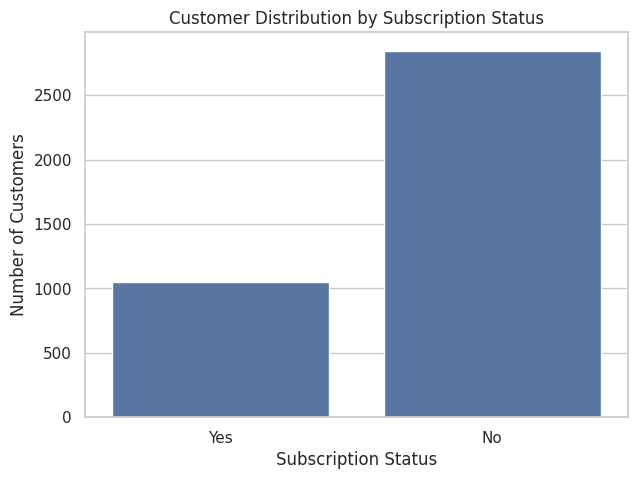

In [ ]:
# Chart Visualization
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x='subscription_status'
)

plt.title(
    'Customer Distribution by Subscription Status'
)

plt.xlabel('Subscription Status')
plt.ylabel('Number of Customers')

plt.show()

#### Subscription vs Purchases Amount

In [ ]:
subscription_purchase = (
    df_clean
    .groupby('subscription_status')
    ['purchase_amount_usd']
    .agg([
        'count',
        'mean',
        'median',
        'sum'
    ])
    .round(2)
)

display(subscription_purchase)

,count,mean,median,sum
subscription_status,,,,
No,2847,59.87,60.00,170436
Yes,1053,59.49,60.00,62645


#### Subsription vs Previous Purchases

In [ ]:
subscription_previous = (
    df_clean
    .groupby('subscription_status')
    ['previous_purchases']
    .agg([
        'mean',
        'median',
        'min',
        'max'
    ])
    .round(2)
)

display(subscription_previous)

,mean,median,min,max
subscription_status,,,,
No,25.08,25.00,1,50
Yes,26.08,26.00,1,50


#### Subscription vs Purchase Frequecy

In [ ]:
frequency_subscription_pct = pd.crosstab(
    df_clean['subscription_status'],
    df_clean['frequency_standardized'],
    normalize='index'
) * 100

frequency_subscription_pct = (
    frequency_subscription_pct
    .round(2)
)

display(frequency_subscription_pct)

frequency_standardized,Annually,Bi-Weekly,Monthly,Quarterly,Weekly
subscription_status,,,,,
No,14.47,27.96,14.19,29.96,13.42
Yes,15.19,27.83,14.15,27.92,14.91


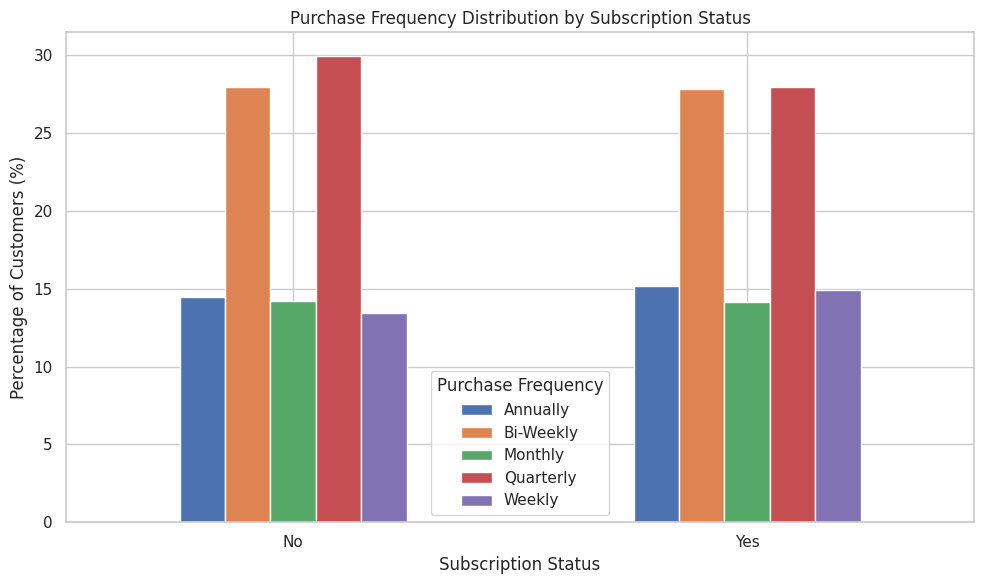

In [ ]:
frequency_subscription_pct.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title(
    'Purchase Frequency Distribution by Subscription Status'
)

plt.xlabel('Subscription Status')
plt.ylabel('Percentage of Customers (%)')

plt.xticks(rotation=0)
plt.legend(title='Purchase Frequency')

plt.tight_layout()
plt.show()

#### Subscription vs Review Rating

In [ ]:
rating_subscription = (
    df_clean
    .groupby('subscription_status')
    ['review_rating']
    .mean()
    .round(2)
)

display(rating_subscription)

,review_rating
subscription_status,
No,3.75
Yes,3.74


Merapihkan Ouput Q1

In [ ]:
subscription_analysis = (
    df_clean
    .groupby('subscription_status')
    .agg(
        customers=('customer_id', 'count'),
        avg_purchase_amount=('purchase_amount_usd', 'mean'),
        median_purchase_amount=('purchase_amount_usd', 'median'),
        avg_previous_purchases=('previous_purchases', 'mean'),
        median_previous_purchases=('previous_purchases', 'median'),
        avg_rating=('review_rating', 'mean')
    )
    .round(2)
)

display(subscription_analysis)

,customers,avg_purchase_amount,median_purchase_amount,avg_previous_purchases,median_previous_purchases,avg_rating
subscription_status,,,,,,
No,2847,59.87,60.00,25.08,25.00,3.75
Yes,1053,59.49,60.00,26.08,26.00,3.74


### Q2. PROMOTION STRATEGY?

**Business Question**:

> "How is promotional usage distributed across subscribers and non-subscribers?"

The analysis examines the **distribution of discount usage across subscription groups**.

Because all subscribers in the dataset are associated with discount usage, the data **does not** provide a subscriber group without discount for a direct comparison.

Therefore, this analysis describes promotional distribution rather than estimating the causal effect of discounts.

Membandingkan:
*   Subscriber + Discount
*   Non-subscriber + Discount
*   Non-subscriber + No Discount

No 'subscriber-without-discount' records are present in the dataset.

#### Create Promotion Group

In [ ]:
promotion_crosstab = pd.crosstab(
    df_clean['subscription_status'],
    df_clean['discount_applied']
)

display(promotion_crosstab)

discount_applied,No,Yes
subscription_status,,
No,2223,624
Yes,0,1053


In [ ]:
# Persentase of Subscription Status and Discount

promotion_percentage = (
    pd.crosstab(
        df_clean['subscription_status'],
        df_clean['discount_applied'],
        normalize='index'
    ) * 100
)

display(promotion_percentage.round(2))

discount_applied,No,Yes
subscription_status,,
No,78.08,21.92
Yes,0.00,100.00


#### Promotion Analysis

In [ ]:
promotion_analysis = (
    df_clean
    .groupby(['subscription_status', 'discount_applied'])
    .agg(
        customers=('customer_id', 'count'),
        avg_purchase_amount=('purchase_amount_usd', 'mean'),
        total_purchase_amount=('purchase_amount_usd', 'sum'),
        avg_previous_purchases=('previous_purchases', 'mean')
    )
    .round(2)
    .reset_index()
)

display(promotion_analysis)

,subscription_status,discount_applied,customers,avg_purchase_amount,total_purchase_amount,avg_previous_purchases
0,No,No,2223,60.13,133670,25.06
1,No,Yes,624,58.92,36766,25.17
2,Yes,Yes,1053,59.49,62645,26.08


#### Promotion Visualization

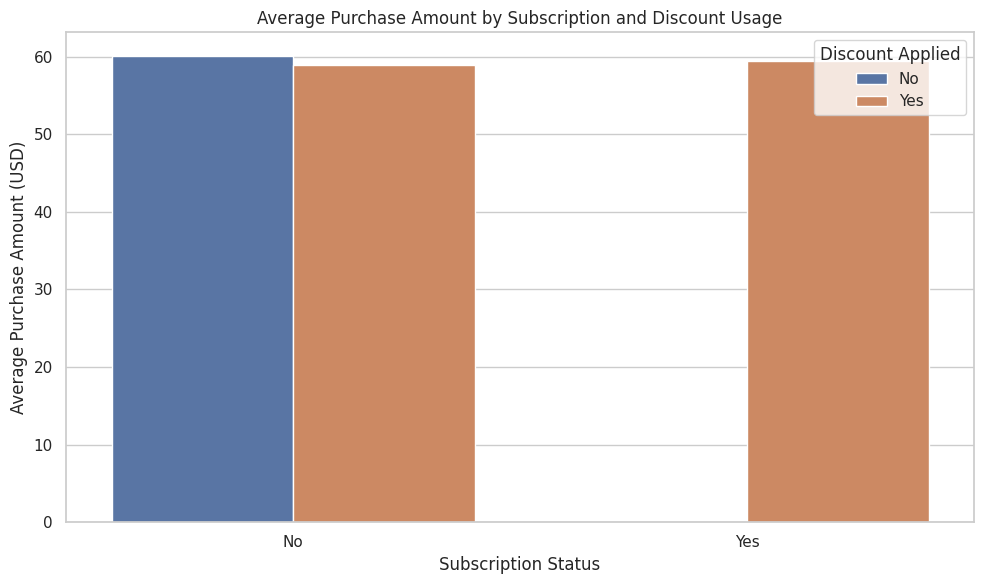

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=promotion_analysis,
    x='subscription_status',
    y='avg_purchase_amount',
    hue='discount_applied'
)

plt.title(
    'Average Purchase Amount by Subscription and Discount Usage'
)

plt.xlabel('Subscription Status')
plt.ylabel('Average Purchase Amount (USD)')
plt.legend(title='Discount Applied')
plt.tight_layout()

plt.show()

### Q3. Product Performance

**Business Question**:
> "Are the most popular products also the largest revenue contributors?"


---



*Popular ≠ necessarily highest revenue*

Produk yang sering dibeli belum tentu menghasilkan revenue terbesar.




#### Product Performance Table

In [ ]:
product_performance = (
    df_clean
    .groupby('item_purchased')
    .agg(
        purchase_count=('customer_id', 'count'),

        total_purchase_amount=(
            'purchase_amount_usd',
            'sum'
        ),

        average_purchase=(
            'purchase_amount_usd',
            'mean'
        )
    )
    .sort_values(
        'total_purchase_amount',
        ascending=False
    )
)

display(product_performance)

,purchase_count,total_purchase_amount,average_purchase
item_purchased,,,
Blouse,171,10410,60.88
Shirt,169,10332,61.14
Dress,166,10320,62.17
Pants,171,10090,59.01
Jewelry,171,10010,58.54
Sunglasses,161,9649,59.93
Belt,161,9635,59.84
Scarf,157,9561,60.90
Sweater,164,9462,57.70


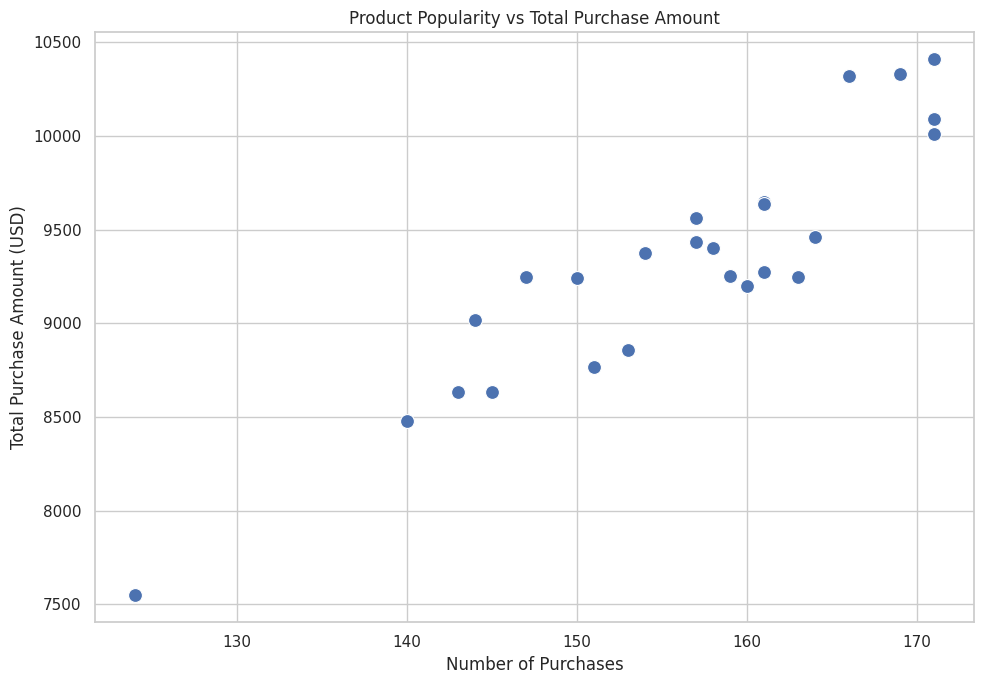

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=product_performance.reset_index(),
    x='purchase_count',
    y='total_purchase_amount',
    s=100
)

plt.title(
    'Product Popularity vs Total Purchase Amount'
)

plt.xlabel('Number of Purchases')
plt.ylabel('Total Purchase Amount (USD)')

plt.tight_layout()
plt.show()

#### TOP 10 MOST PURCHASED PRODUCTS

In [ ]:
top_popular_products = (
    product_performance
    .sort_values(
        'purchase_count',
        ascending=False
    )
    .head(10)
)

display(top_popular_products)

,purchase_count,total_purchase_amount,average_purchase
item_purchased,,,
Blouse,171,10410,60.88
Jewelry,171,10010,58.54
Pants,171,10090,59.01
Shirt,169,10332,61.14
Dress,166,10320,62.17
Sweater,164,9462,57.70
Jacket,163,9249,56.74
Belt,161,9635,59.84
Sunglasses,161,9649,59.93


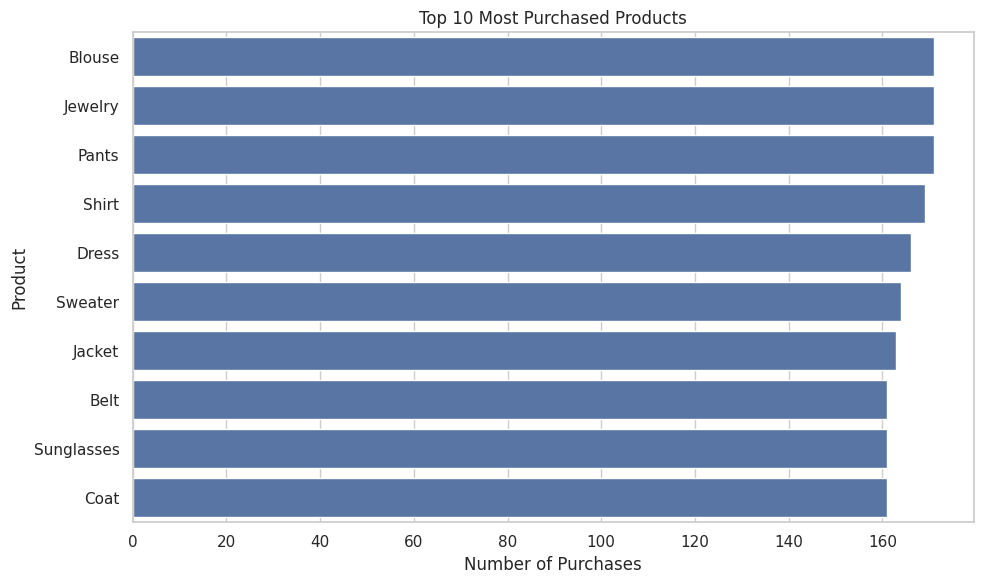

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_popular_products.reset_index(),
    x='purchase_count',
    y='item_purchased'
)

plt.title(
    'Top 10 Most Purchased Products'
)

plt.xlabel('Number of Purchases')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

#### Top 10 Products by Revenue

In [ ]:
top_revenue_products = (
    product_performance
    .sort_values(
        'total_purchase_amount',
        ascending=False
    )
    .head(10)
)

display(top_revenue_products)

,purchase_count,total_purchase_amount,average_purchase
item_purchased,,,
Blouse,171,10410,60.88
Shirt,169,10332,61.14
Dress,166,10320,62.17
Pants,171,10090,59.01
Jewelry,171,10010,58.54
Sunglasses,161,9649,59.93
Belt,161,9635,59.84
Scarf,157,9561,60.90
Sweater,164,9462,57.70


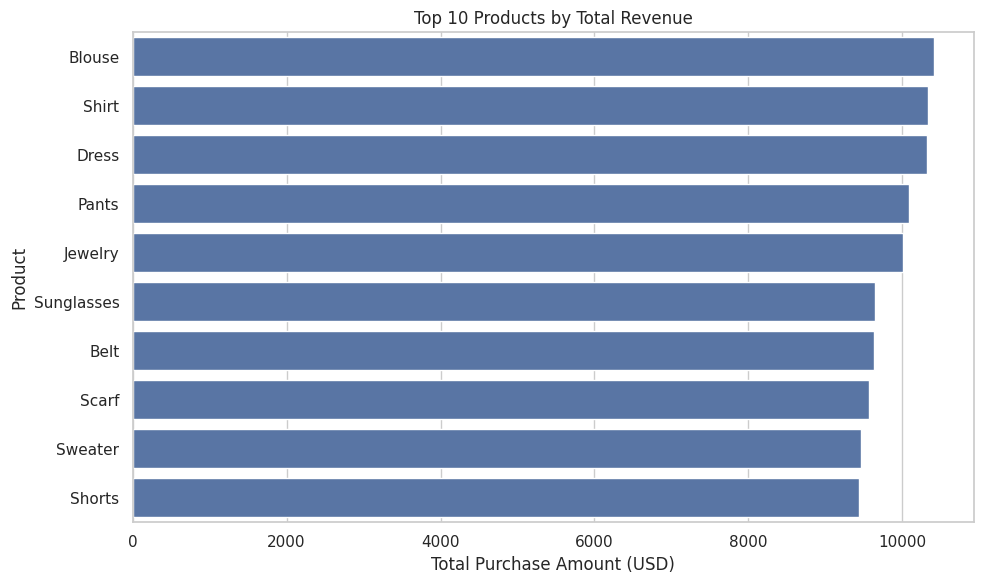

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_revenue_products.reset_index(),
    x='total_purchase_amount',
    y='item_purchased'
)

plt.title(
    'Top 10 Products by Total Revenue'
)

plt.xlabel('Total Purchase Amount (USD)')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

#### Popularity vs Revenue

In [ ]:
product_comparison = product_performance.copy()

product_comparison['popularity_rank'] = (
    product_comparison['purchase_count']
    .rank(
        method='min',
        ascending=False
    )
)

product_comparison['revenue_rank'] = (
    product_comparison['total_purchase_amount']
    .rank(
        method='min',
        ascending=False
    )
)

product_comparison['rank_difference'] = (
    product_comparison['popularity_rank']
    -
    product_comparison['revenue_rank']
)

display(
    product_comparison
    .sort_values(
        'rank_difference'
    )
)

,purchase_count,total_purchase_amount,average_purchase,popularity_rank,revenue_rank,rank_difference
item_purchased,,,,,,
Jacket,163,9249,56.74,7.00,15.00,-8.00
Sandals,160,9200,57.50,11.00,18.00,-7.00
Coat,161,9275,57.61,8.00,13.00,-5.00
Jewelry,171,10010,58.54,1.00,5.00,-4.00
Sweater,164,9462,57.70,6.00,9.00,-3.00
Hoodie,151,8767,58.06,18.00,21.00,-3.00
Handbag,153,8857,57.89,17.00,20.00,-3.00
Pants,171,10090,59.01,1.00,4.00,-3.00
Sneakers,145,8635,59.55,21.00,23.00,-2.00


#### Category vs Performance

In [ ]:
category_performance = (
    df_clean
    .groupby('category')
    .agg(
        purchase_count=('customer_id', 'count'),
        total_purchase_amount=('purchase_amount_usd', 'sum'),
        average_purchase_amount=('purchase_amount_usd', 'mean'),
        average_rating=('review_rating', 'mean')
    )
    .round(2)
    .sort_values(
        'total_purchase_amount',
        ascending=False
    )
)

display(category_performance)

,purchase_count,total_purchase_amount,average_purchase_amount,average_rating
category,,,,
Clothing,1737,104264,60.03,3.72
Accessories,1240,74200,59.84,3.77
Footwear,599,36093,60.26,3.79
Outerwear,324,18524,57.17,3.75


### Q4. Purchase Behavior

Business Question


> "How does purchase frequency relate to purchasing behavior?"


The analysis compares standardized purchase-frequency groups based on:
- Average purchase amount
- Average previous purchases
- Customer count

The purpose is to identify whether customers with different stated purchasing frequencies show different purchasing patterns.


#### Frequency Distribution and Analysis

In [ ]:
#Frequency Distribution
frequency_order = [
    'Weekly',
    'Bi-Weekly',
    'Monthly',
    'Quarterly',
    'Annually'
]

df_clean['frequency_standardized'] = pd.Categorical(
    df_clean['frequency_standardized'],
    categories=frequency_order,
    ordered=True
)

# Frequency Analysis
frequency_analysis = (
    df_clean
    .groupby(
        'frequency_standardized',
        observed=True
    )
    .agg(
        customers=('customer_id', 'count'),
        avg_purchase_amount=('purchase_amount_usd', 'mean'),
        avg_previous_purchases=('previous_purchases', 'mean'),
        avg_rating=('review_rating', 'mean')
    )
    .round(2)
)

display(frequency_analysis)

,customers,avg_purchase_amount,avg_previous_purchases,avg_rating
frequency_standardized,,,,
Weekly,539,58.97,25.77,3.76
Bi-Weekly,1089,59.88,25.03,3.73
Monthly,553,59.33,25.28,3.78
Quarterly,1147,60.03,25.89,3.75
Annually,572,60.17,24.56,3.76


#### Frequency vs Purchase Amount

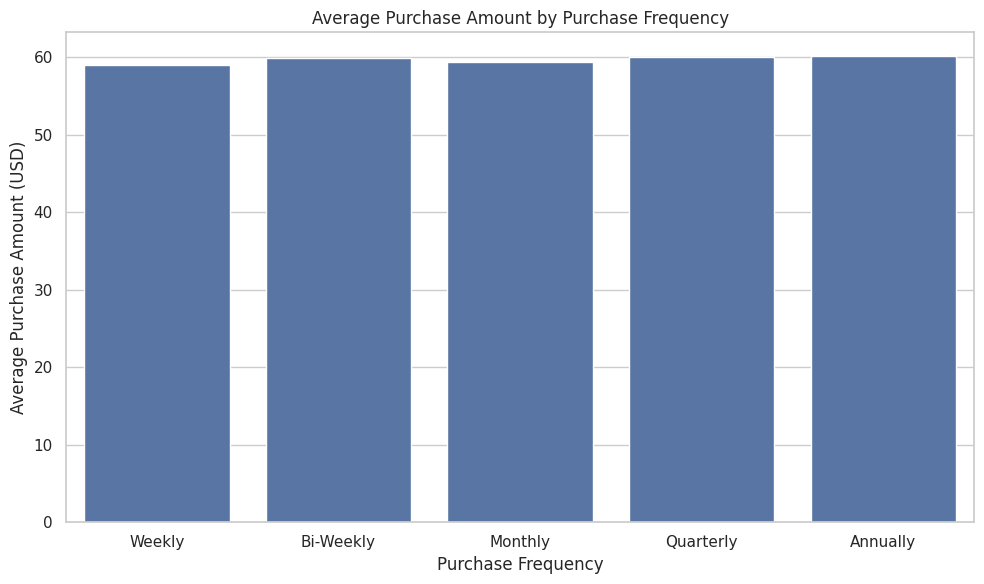

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=frequency_analysis.reset_index(),
    x='frequency_standardized',
    y='avg_purchase_amount'
)

plt.title(
    'Average Purchase Amount by Purchase Frequency'
)

plt.xlabel('Purchase Frequency')
plt.ylabel('Average Purchase Amount (USD)')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

#### Frequency vs Previous Purchases

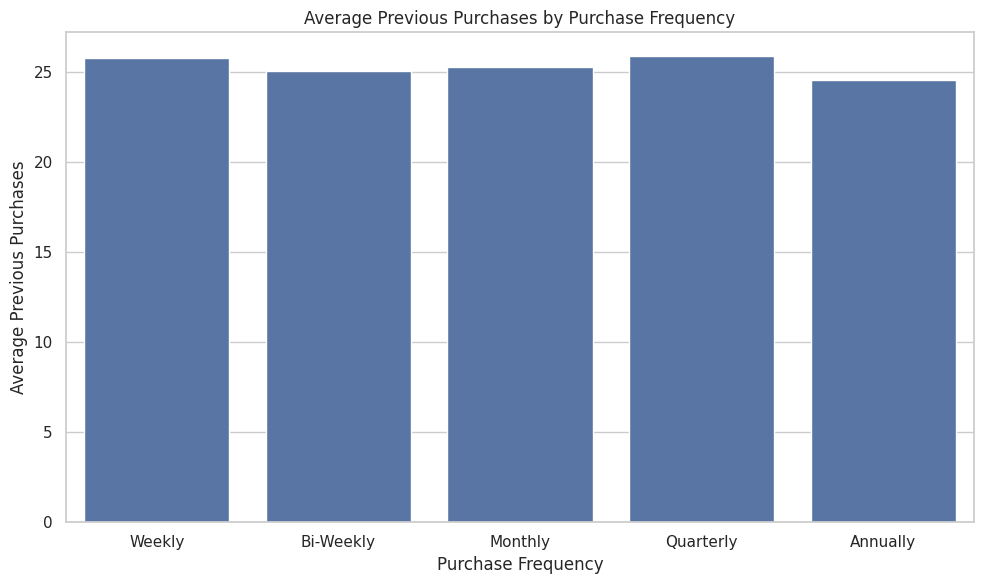

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=frequency_analysis.reset_index(),
    x='frequency_standardized',
    y='avg_previous_purchases'
)

plt.title(
    'Average Previous Purchases by Purchase Frequency'
)

plt.xlabel('Purchase Frequency')
plt.ylabel('Average Previous Purchases')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Q5. Customer Experience

Business Question


> "Is customer satisfaction associated with purchasing behavior?"

Review Rating is compared with:
- Purchase Amount
- Previous Purchases

Pearson correlation is used to assess the strength and direction of linear relationships.

Correlation is interpreted as an association, not as evidence of causation.

#### Correlation matrix

In [ ]:
numeric_columns = [
    'age',
    'purchase_amount_usd',
    'review_rating',
    'previous_purchases'
]

correlation_matrix = (
    df_clean[numeric_columns]
    .corr()
)

display(
    correlation_matrix.round(2)
)

,age,purchase_amount_usd,review_rating,previous_purchases
age,1.00,-0.01,-0.02,0.04
purchase_amount_usd,-0.01,1.00,0.03,0.01
review_rating,-0.02,0.03,1.00,0.00
previous_purchases,0.04,0.01,0.00,1.00


#### Correlation Heatmap

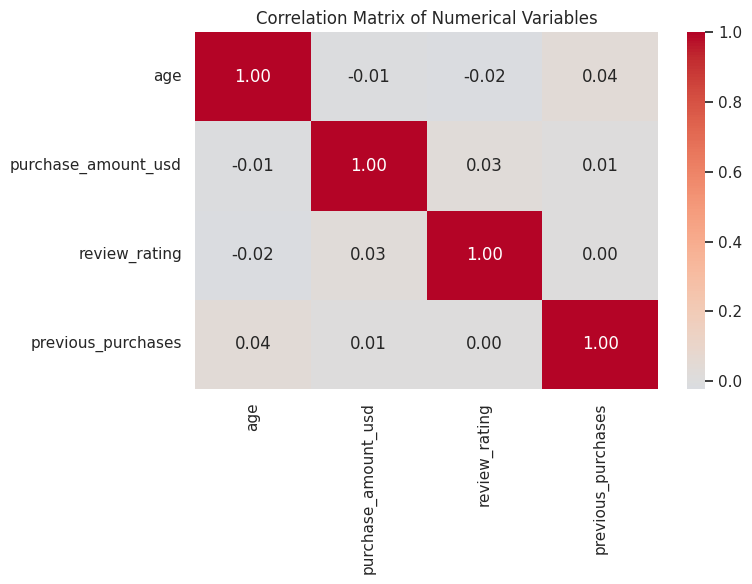

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title(
    'Correlation Matrix of Numerical Variables'
)

plt.tight_layout()
plt.show()

#### Rating vs Purchase Amount

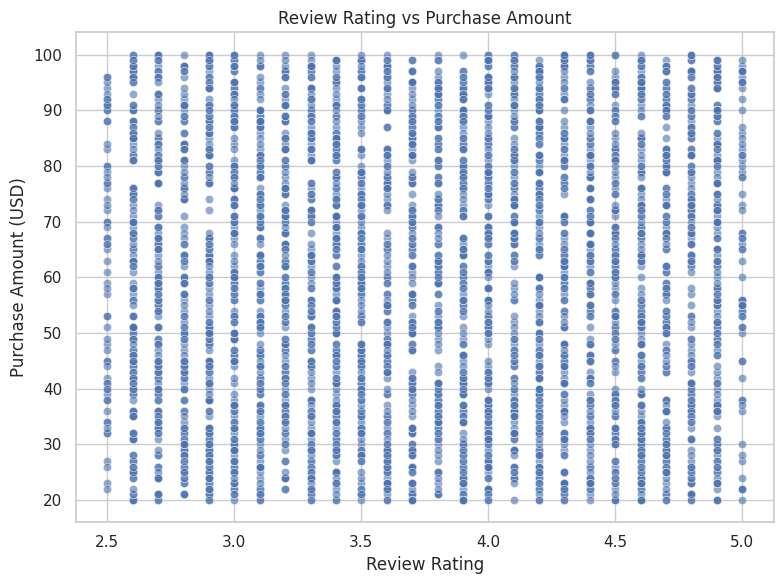

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_clean,
    x='review_rating',
    y='purchase_amount_usd',
    alpha=0.6
)

plt.title(
    'Review Rating vs Purchase Amount'
)

plt.xlabel('Review Rating')
plt.ylabel('Purchase Amount (USD)')

plt.tight_layout()
plt.show()

#### Rating vs Previous Purchases

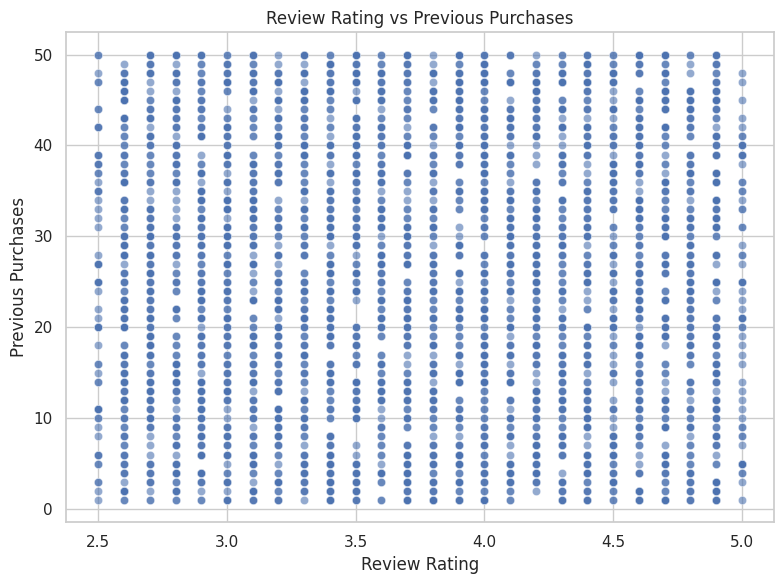

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_clean,
    x='review_rating',
    y='previous_purchases',
    alpha=0.6
)

plt.title(
    'Review Rating vs Previous Purchases'
)

plt.xlabel('Review Rating')
plt.ylabel('Previous Purchases')

plt.tight_layout()
plt.show()

In [ ]:
# Automatic Interpretation

rating_purchase_corr = correlation_matrix.loc[
    'review_rating',
    'purchase_amount_usd'
]

rating_previous_corr = correlation_matrix.loc[
    'review_rating',
    'previous_purchases'
]

print(
    f"Correlation between Review Rating and Purchase Amount: "
    f"{rating_purchase_corr:.2f}"
)

print(
    f"Correlation between Review Rating and Previous Purchases: "
    f"{rating_previous_corr:.2f}"
)

Correlation between Review Rating and Purchase Amount: 0.03
Correlation between Review Rating and Previous Purchases: 0.00


#### Supporting Analysis (Based on Age)

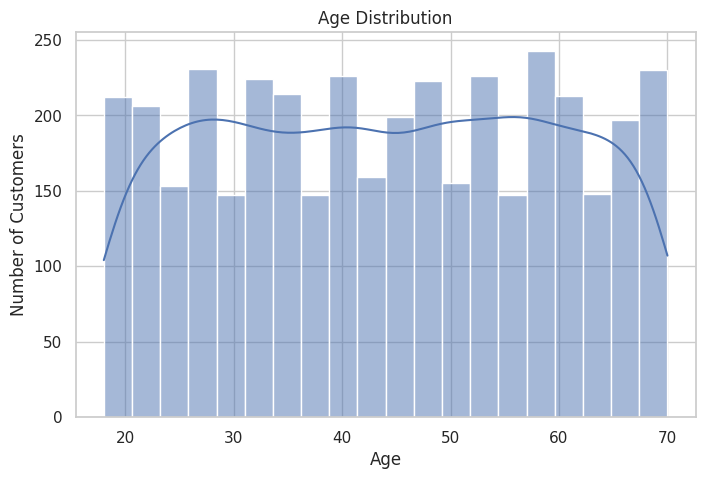

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x='age',
    bins=20,
    kde=True
)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.show()

#### Gender Analysis

In [ ]:
gender_analysis = (
    df_clean
    .groupby('gender')
    .agg(
        customers=('customer_id', 'count'),
        avg_purchase_amount=('purchase_amount_usd', 'mean'),
        total_purchase_amount=('purchase_amount_usd', 'sum'),
        avg_rating=('review_rating', 'mean')
    )
    .round(2)
)

display(gender_analysis)

,customers,avg_purchase_amount,total_purchase_amount,avg_rating
gender,,,,
Female,1248,60.25,75191,3.74
Male,2652,59.54,157890,3.75


#### Location Analysis

In [ ]:
location_analysis = (
    df_clean
    .groupby('location')
    .agg(
        customers=('customer_id', 'count'),

        total_purchase_amount=(
            'purchase_amount_usd',
            'sum'
        ),

        avg_purchase=(
            'purchase_amount_usd',
            'mean'

        )
    )
    .round(2)
    .sort_values(
        'total_purchase_amount',
        ascending=False
    )
)

display(
    location_analysis.head(10)
)

,customers,total_purchase_amount,avg_purchase
location,,,
Montana,96,5784,60.25
Illinois,92,5617,61.05
California,95,5605,59.00
Idaho,93,5587,60.08
Nevada,87,5514,63.38
Alabama,89,5261,59.11
New York,87,5257,60.43
North Dakota,83,5220,62.89
West Virginia,81,5174,63.88


#### Payment Method

In [ ]:
payment_analysis = (
    df_clean
    .groupby('payment_method')
    .agg(
        transactions=('customer_id', 'count'),

        total_purchase_amount=(
            'purchase_amount_usd',
            'sum'
        ),

        avg_purchase=(
            'purchase_amount_usd',
            'mean'
        )
    )
    .round(2)
    .sort_values(
        'total_purchase_amount',
        ascending=False
    )
)

display(payment_analysis)

,transactions,total_purchase_amount,avg_purchase
payment_method,,,
Credit Card,671,40310,60.07
PayPal,677,40109,59.25
Cash,670,40002,59.70
Debit Card,636,38742,60.92
Venmo,634,37374,58.95
Bank Transfer,612,36544,59.71


#### Shipping Type

In [ ]:
shipping_analysis = (
    df_clean
    .groupby('shipping_type')
    .agg(
        transactions=('customer_id', 'count'),
        avg_purchase=('purchase_amount_usd','mean'),
        avg_rating=('review_rating', 'mean')
    )
    .round(2)
)

display(shipping_analysis)

,transactions,avg_purchase,avg_rating
shipping_type,,,
2-Day Shipping,627,60.73,3.76
Express,646,60.48,3.78
Free Shipping,675,60.41,3.72
Next Day Air,648,58.63,3.72
Standard,654,58.46,3.82
Store Pickup,650,59.89,3.71


#### Seasonal Analysis

In [ ]:
season_analysis = (
    df_clean
    .groupby('season')
    .agg(
        customers=('customer_id', 'count'),
        total_purchase_amount=('purchase_amount_usd', 'sum'),
        avg_purchase_amount=('purchase_amount_usd', 'mean'),
        avg_rating=('review_rating', 'mean')
    )
    .round(2)
    .sort_values(
        'total_purchase_amount',
        ascending=False
    )
)

display(season_analysis)

,customers,total_purchase_amount,avg_purchase_amount,avg_rating
season,,,,
Fall,975,60018,61.56,3.73
Spring,999,58679,58.74,3.79
Winter,971,58607,60.36,3.75
Summer,955,55777,58.41,3.73


#### Final KPI Summary

In [ ]:
summary = {
    'Total Customers':
        df_clean['customer_id'].nunique(),

    'Total Purchase Amount':
        df_clean['purchase_amount_usd'].sum(),

    'Average Purchase Amount':
        df_clean['purchase_amount_usd'].mean(),

    'Average Rating':
        df_clean['review_rating'].mean(),

    'Average Previous Purchases':
        df_clean['previous_purchases'].mean(),

    'Subscription Rate (%)':
        df_clean['subscription_status']
        .eq('Yes')
        .mean() * 100
}

## Key Findings

Based on the exploratory analysis, the following key findings were identified:

1. **Customer Engagement**

    Subscribers represent approximately 27% of the customer records. Their average purchase amount is very similar to non-subscribers, while their average previous purchase count is slightly higher.

2. **Promotion Usage**

    All subscribers in the dataset are associated with discount usage, while only a portion of non-subscribers use discounts. Because there is no subscriber-without-discount group, the effect of discount usage cannot be isolated.

3. **Product Performance**
    
    Product popularity and purchase-value contribution are not identical. Several products have similar purchase volumes but different total purchase amounts, indicating that volume alone is not sufficient to evaluate product performance.

4. **Purchase Behavior**
    
    After standardizing overlapping frequency labels, purchasing frequency can be compared across five meaningful groups: Weekly, Bi-Weekly, Monthly, Quarterly, and Annually. The analysis evaluates whether these groups differ in average purchase amount and previous purchase activity.

    Purchase frequency does not show a clear positive relationship with average purchase amount. Annual customers have the highest average purchase amount ($60.17), while Weekly customers have the lowest ($58.97). Quarterly customers have the highest average previous purchases (25.89).

5. **Customer Experience**
    
    Review ratings show little to no meaningful linear association with purchase amount and previous purchase activity in this dataset.

6.  **Seasonal Pattern**

    Fall records the highest total and average purchase amount among the four recorded seasons, although the dataset does not contain transaction dates and therefore cannot be used to analyze actual trends over time.


###**Business Recommendations**

Based on the analysis, the following recommendations can be considered:
1. **Evaluate Subscription Based on Engagement, Not Purchase Amount Alone**

    Since subscribers do not show a substantially higher average purchase amount, subscription performance should also be evaluated using previous purchase activity and purchase-frequency distribution.

2. **Review the Relationship Between Subscription and Promotional Strategy**

    Because all subscribers in the dataset are associated with discount usage, future analysis should separate subscription benefits from promotional incentives to determine which factor is associated with customer engagement.

3. **Evaluate Products Using Both Volume and Monetary Contribution**

    Product performance should consider both purchase volume and total purchase amount. High-volume products are not necessarily the strongest contributors in monetary terms.

4. **Use Purchase Frequency for Customer Profiling**

    Standardized purchasing frequency can be used to profile customer behavior and identify groups with different purchasing patterns.

5. **Do Not Overinterpret Review Ratings**

    Since review ratings show little linear association with purchasing variables, marketing decisions should not assume that higher ratings automatically correspond to higher purchase amounts or repeat activity.

6. **Improve Future Data Collection**

    For more advanced customer analysis, future datasets should include transaction dates, transaction IDs, quantities, prices, and repeated customer records. These fields would enable deeper analysis such as recency, frequency, monetary value, customer lifetime value, and cohort analysis.

#### **Data Limitations**

Several limitations should be considered when interpreting the results:

1. The dataset contains one record per Customer ID, so it does not represent
   a complete multi-transaction history for each customer.

2. The `Previous Purchases` variable represents a summarized count of previous
   purchases rather than individual historical transactions.

3. Therefore, this dataset is not suitable for traditional RFM analysis,
   cohort analysis, or customer lifetime value analysis.

4. The analysis identifies associations and patterns rather than causal
   relationships.

5. The dataset is suitable for exploratory and portfolio analysis, but the
   findings should not be generalized to all retail customers without
   additional real-world data.

### Export Clean Dataset

In [ ]:
output_path = '/content/Customer_Shopping_Behavior_Clean_Update2.csv'

df_clean.to_csv(
    output_path,
    index=False
)

print(f"Clean dataset saved to: {output_path}")
print(f"Rows: {df_clean.shape[0]:,}")
print(f"Columns: {df_clean.shape[1]:,}")

Clean dataset saved to: /content/Customer_Shopping_Behavior_Clean_Update2.csv
Rows: 3,900
Columns: 18


In [ ]:
# Download

from google.colab import files

files.download(output_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>